In [ ]:
# Install yfinance for stock data
!pip install yfinance --quiet

# Import libraries
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Define tickers and date range
tickers = ['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'NVDA']
start_date = '2023-01-01'
end_date = '2025-08-19'

# Download adjusted close prices, explicitly setting auto_adjust and suppressing progress output
data = yf.download(tickers, start=start_date, end=end_date, auto_adjust=True, progress=False)
data = data.xs('Close', level=0, axis=1)

# Display first 5 rows
print(data.head())
print(f"\nDataset shape: {data.shape}")
# data.isnull().sum()

Ticker            AAPL       AMZN      GOOGL        MSFT       NVDA
Date                                                               
2023-01-03  122.876724  85.820000  88.279961  232.510559  14.267299
2023-01-04  124.144119  85.139999  87.249748  222.339783  14.699853
2023-01-05  122.827621  83.120003  85.387474  215.750153  14.217465
2023-01-06  127.346939  86.080002  86.516731  218.292862  14.809485
2023-01-09  127.867645  87.360001  87.190315  220.418228  15.575922

Dataset shape: (658, 5)


In [ ]:
# Calculate daily percentage returns
daily_returns = data.pct_change()

# Drop the first row (NaN from pct_change)
daily_returns = daily_returns.dropna()

print(daily_returns.head())
print(daily_returns.tail())
print(f"\nDaily returns shape: {daily_returns.shape}")

Ticker          AAPL      AMZN     GOOGL      MSFT      NVDA
Date                                                        
2023-01-04  0.010314 -0.007924 -0.011670 -0.043743  0.030318
2023-01-05 -0.010605 -0.023726 -0.021344 -0.029638 -0.032816
2023-01-06  0.036794  0.035611  0.013225  0.011785  0.041640
2023-01-09  0.004089  0.014870  0.007786  0.009736  0.051753
2023-01-10  0.004457  0.028732  0.004544  0.007617  0.017981
Ticker          AAPL      AMZN     GOOGL      MSFT      NVDA
Date                                                        
2025-08-12  0.010872  0.000768  0.011642  0.014317  0.006042
2025-08-13  0.016024  0.013952 -0.006787 -0.016363 -0.008572
2025-08-14 -0.002357  0.028589  0.004852  0.003650  0.002368
2025-08-15 -0.005112  0.000216  0.004730 -0.004421 -0.008625
2025-08-18 -0.003023  0.001991 -0.001962 -0.005902  0.008645

Daily returns shape: (657, 5)


In [ ]:
# Cumulative returns: (1 + daily_return) multiplied together
cumulative_returns = (1 + daily_returns).cumprod()

print("=== FIRST 5 ROWS OF CUMULATIVE RETURNS ===")
print(cumulative_returns.head())

print("=== LAST 5 ROWS OF CUMULATIVE RETURNS ===")
print(cumulative_returns.tail())

print("\n=== FINAL CUMULATIVE RETURN FOR EACH STOCK ===")
print(cumulative_returns.iloc[-1])

=== FIRST 5 ROWS OF CUMULATIVE RETURNS ===
Ticker          AAPL      AMZN     GOOGL      MSFT      NVDA
Date                                                        
2023-01-04  1.010314  0.992076  0.988330  0.956257  1.030318
2023-01-05  0.999600  0.968539  0.967235  0.927916  0.996507
2023-01-06  1.036380  1.003030  0.980027  0.938851  1.038002
2023-01-09  1.040617  1.017945  0.987657  0.947992  1.091722
2023-01-10  1.045255  1.047192  0.992145  0.955213  1.111352
=== LAST 5 ROWS OF CUMULATIVE RETURNS ===
Ticker          AAPL      AMZN     GOOGL      MSFT       NVDA
Date                                                         
2025-08-12  1.862068  2.580634  2.295326  2.253918  12.806344
2025-08-13  1.891906  2.616639  2.279749  2.217037  12.696572
2025-08-14  1.887447  2.691447  2.290811  2.225128  12.726636
2025-08-15  1.877798  2.692030  2.301648  2.215290  12.616865
2025-08-18  1.872122  2.697390  2.297133  2.202215  12.725936

=== FINAL CUMULATIVE RETURN FOR EACH STOCK ===
Ticker

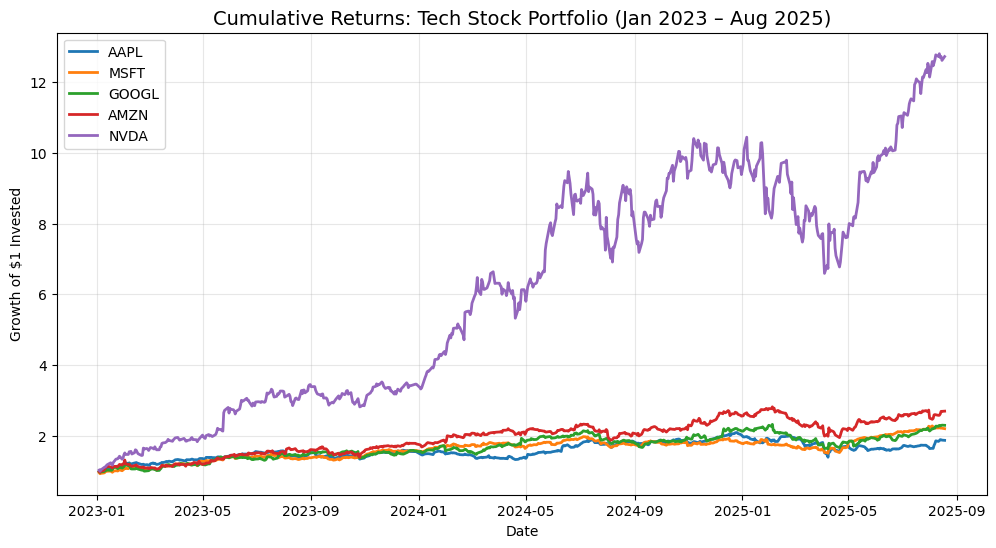

In [ ]:
# Plot cumulative returns over time
plt.figure(figsize=(12, 6))
for ticker in tickers:
    plt.plot(cumulative_returns.index, cumulative_returns[ticker], label=ticker, linewidth=2)

plt.title('Cumulative Returns: Tech Stock Portfolio (Jan 2023 – Aug 2025)', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Growth of $1 Invested')
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
# Annualized volatility = daily std dev × sqrt(252 trading days)
volatility = daily_returns.std() * np.sqrt(252)

print("=== ANNUALIZED VOLATILITY ===")
print(volatility.sort_values(ascending=False))

=== ANNUALIZED VOLATILITY ===
Ticker
NVDA     0.520258
AMZN     0.321361
GOOGL    0.301678
AAPL     0.262903
MSFT     0.238886
dtype: float64


In [ ]:
# Annualized return
annual_return = daily_returns.mean() * 252

# Sharpe ratio (assuming 0% risk-free rate for simplicity)
sharpe_ratio = annual_return / volatility

# Combine into a summary table
summary = pd.DataFrame({
    'Annual Return': annual_return,
    'Volatility': volatility,
    'Sharpe Ratio': sharpe_ratio
})

print("=== PORTFOLIO SUMMARY ===")
print(summary.round(4))

=== PORTFOLIO SUMMARY ===
        Annual Return  Volatility  Sharpe Ratio
Ticker                                         
AAPL           0.2749      0.2629        1.0455
AMZN           0.4323      0.3214        1.3453
GOOGL          0.3647      0.3017        1.2088
MSFT           0.3313      0.2389        1.3869
NVDA           1.1104      0.5203        2.1343


=== CORRELATION MATRIX ===
Ticker   AAPL   AMZN  GOOGL   MSFT   NVDA
Ticker                                   
AAPL    1.000  0.488  0.469  0.515  0.390
AMZN    0.488  1.000  0.598  0.639  0.474
GOOGL   0.469  0.598  1.000  0.541  0.421
MSFT    0.515  0.639  0.541  1.000  0.549
NVDA    0.390  0.474  0.421  0.549  1.000


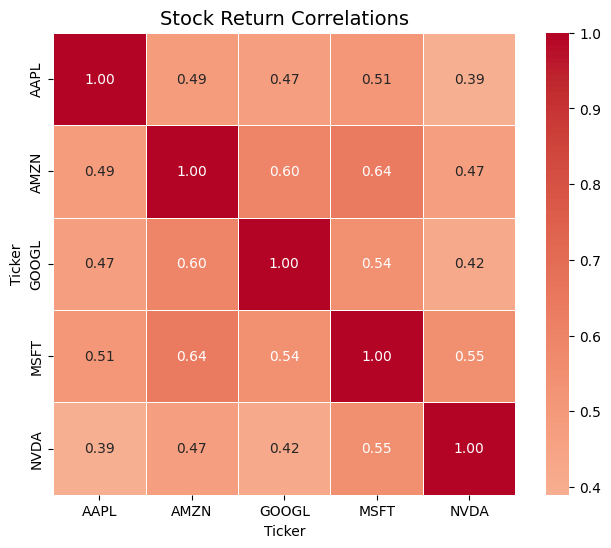

In [ ]:
# Correlation matrix of daily returns
corr_matrix = daily_returns.corr()

print("=== CORRELATION MATRIX ===")
print(corr_matrix.round(3))

# Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0,
            square=True, linewidths=0.5, fmt='.2f')
plt.title('Stock Return Correlations', fontsize=14)
plt.show()

In [ ]:
# Equal weights: 20% each
weights_equal = np.array([0.2, 0.2, 0.2, 0.2, 0.2])

# Portfolio return = weighted average of individual returns
portfolio_return_equal = np.dot(weights_equal, annual_return)

# Portfolio volatility = sqrt(weights^T × covariance_matrix × weights)
cov_matrix = daily_returns.cov() * 252  # Annualized covariance
portfolio_vol_equal = np.sqrt(np.dot(weights_equal.T, np.dot(cov_matrix, weights_equal)))

# Portfolio Sharpe
portfolio_sharpe_equal = portfolio_return_equal / portfolio_vol_equal

print("=== EQUAL-WEIGHT PORTFOLIO ===")
print(f"Expected Annual Return: {portfolio_return_equal:.2%}")
print(f"Annual Volatility:      {portfolio_vol_equal:.2%}")
print(f"Sharpe Ratio:           {portfolio_sharpe_equal:.4f}")

=== EQUAL-WEIGHT PORTFOLIO ===
Expected Annual Return: 50.27%
Annual Volatility:      25.60%
Sharpe Ratio:           1.9634


In [ ]:
from scipy.optimize import minimize

# Objective: minimize negative Sharpe (equivalent to maximizing Sharpe)
def neg_sharpe(weights):
    p_return = np.dot(weights, annual_return)
    p_vol = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))
    return -(p_return / p_vol)

# Constraints: weights sum to 1, no short selling (0 to 1)
constraints = {'type': 'eq', 'fun': lambda w: np.sum(w) - 1}
bounds = [(0, 1) for _ in range(len(tickers))]

# Optimize
result = minimize(neg_sharpe, weights_equal, method='SLSQP', bounds=bounds, constraints=constraints)
weights_optimal = result.x

# Calculate optimal portfolio metrics
portfolio_return_opt = np.dot(weights_optimal, annual_return)
portfolio_vol_opt = np.sqrt(np.dot(weights_optimal.T, np.dot(cov_matrix, weights_optimal)))
portfolio_sharpe_opt = portfolio_return_opt / portfolio_vol_opt

print("=== SHARPE-OPTIMIZED PORTFOLIO ===")
for ticker, weight in zip(tickers, weights_optimal):
    print(f"{ticker}: {weight:.2%}")
print(f"\nExpected Annual Return: {portfolio_return_opt:.2%}")
print(f"Annual Volatility:      {portfolio_vol_opt:.2%}")
print(f"Sharpe Ratio:           {portfolio_sharpe_opt:.4f}")

=== SHARPE-OPTIMIZED PORTFOLIO ===
AAPL: 4.57%
MSFT: 15.86%
GOOGL: 12.07%
AMZN: 2.64%
NVDA: 64.87%

Expected Annual Return: 85.41%
Annual Volatility:      39.26%
Sharpe Ratio:           2.1757


In [ ]:
# Export 1: Daily prices + cumulative returns (for trend charts)
export_prices = cumulative_returns.copy()
export_prices['Date'] = export_prices.index
export_prices.to_csv('cumulative_returns.csv', index=False)
print("Exported: cumulative_returns.csv")

# Export 2: Portfolio summary table (for KPI cards and comparison)
summary_df = pd.DataFrame({
    'Stock': tickers + ['Equal-Weight Portfolio', 'Sharpe-Optimized'],
    'Annual_Return': list(annual_return) + [portfolio_return_equal, portfolio_return_opt],
    'Volatility': list(volatility) + [portfolio_vol_equal, portfolio_vol_opt],
    'Sharpe_Ratio': list(sharpe_ratio) + [portfolio_sharpe_equal, portfolio_sharpe_opt],
    'Weight_AAPL': [1,0,0,0,0, 0.2, weights_optimal[0]],
    'Weight_MSFT': [0,1,0,0,0, 0.2, weights_optimal[1]],
    'Weight_GOOGL': [0,0,1,0,0, 0.2, weights_optimal[2]],
    'Weight_AMZN': [0,0,0,1,0, 0.2, weights_optimal[3]],
    'Weight_NVDA': [0,0,0,0,1, 0.2, weights_optimal[4]]
})

summary_df.to_csv('portfolio_summary.csv', index=False)
print("Exported: portfolio_summary.csv")

Exported: cumulative_returns.csv
Exported: portfolio_summary.csv
